### **<강남 출발 주요 경로의 도로 구조 기반 KPI 및 ETA 분석>**
본 노트북은 **강남 출발 주요 경로의 도로 구조 특성을 분석**하여  
운전 난이도, 교차로 밀도, 회전 수 등을 KPI로 정량화하고,  
  
이를 기반으로
- 경로 안내 복잡도
- ETA 시뮬레이션 기반 구조 영향 분석
- 내비게이션 서비스 지표 설계  
  
가능성을 탐색하는 것을 목적으로 한다.

---

#### **1. 분석 목표**
본 분석의 목표는 다음과 같다.  

**1️⃣ 도로 구조 KPI 산출**  
- Distance (거리)
- Intersections (교차로 수)
- Intersection Density (교차로 밀도)
- Turns (회전 수)
- Complexity Score (경로 복잡도 지수)  
  
**2️⃣ KPI 기반 ETA 시뮬레이션**  
  
**3️⃣ 도로 구조 기반 서비스 지표 설계 가능성 탐색**

---

#### **2. OSM 기반 도로 네트워크 구축**
OpenStreetMap(OSM)을 활용하여 **강남역 기준 20km 반경** 도로 네트워크를 수집한다.  
  
강남역을 중심으로 반경 20km를 설정한 이유는  
서울 주요 업무지구(여의도, 광화문, 잠실 등)를 포함하는 범위이면서,  
도심/외곽 경로를 모두 포함할 수 있는 분석 범위이기 때문이다.  
  
또한 지나치게 넓은 범위를 사용할 경우  
불필요한 계산 비용 증가 및 분석 해석력이 저하될 수 있어 적절한 범위로 제한하였다.

In [1]:
import osmnx as ox
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

center_point = (37.4982, 127.0275)

G = ox.graph_from_point(
    center_point,
    dist=20000,
    network_type="drive",
    simplify=True
)


print("노드 수:", len(G.nodes))   # 교차로
print("도로 수:", len(G.edges))   # 도로

노드 수: 97910
도로 수: 265686


---

#### **3. 분석 지점 정의**
목적지는 서울 내 주요 생활/업무 거점을 기준으로 선정하였다.  
- **강남/삼성/잠실**: 동남권 핵심 상업지구
- **판교**: 수도권 외곽 IT/업무지구
- **여의도/광화문**: 주요 업무 중심지 (CBD)
- **성수**: 최근 상업/문화 중심지
- **사당**: 교통 요충지
- **하남**: 외곽 주거/신도시  
  
이를 통해 도심/준도심/외곽 경로를 모두 포함하도록 구성하였다.

In [ ]:
start = (37.4982, 127.0275)

destinations = {
    "Samseong": (37.5093, 127.0632),    # 삼성역
    "Jamsil": (37.5134, 127.1000),      # 잠실역
    "Pangyo": (37.3949, 127.1112),      # 판교역
    "Yeouido": (37.5218, 126.9240),     # 여의도역
    "Gwanghwamun": (37.5718, 126.9765), # 광화문역
    "Seongsu": (37.5454, 127.0559),     # 성수역
    "Sadang": (37.4767, 126.9816),      # 사당역
    "Hanam": (37.5428, 127.2228),       # 하남검단역
}

---

#### **4. 좌표 → 도로 네트워크 노드 매핑**
OSM 도로 네트워크에서는 위치가 좌표가 아니라 노드 ID로 표현된다.  
따라서 출발지와 목적지 좌표를 **가장 가까운 도로 노드로 변환**한다.

In [3]:
# 출발지 노드
start_node = ox.distance.nearest_nodes(G, start[1], start[0])

# 목적지 노드
nodes = {}
for name, (lat, lon) in destinations.items():
    nodes[name] = ox.distance.nearest_nodes(G, lon, lat)

---

#### **5. 지도 기반 경로 시각화**
강남 출발 주요 목적지까지의 **실제 도로 경로**를 지도에 시각화한다.  
  
이를 통해
- 도심 밀집 경로
- 직선형 경로
- 외곽 이동 경로  
  
등 **경로 구조 차이**를 직관적으로 확인할 수 있다.  
  
본 분석에서는 **거리 기반 최단 경로**를 기준으로 경로를 산출하였다.  
  
이는 실제 내비게이션의 시간 기반 최적 경로와는 차이가 있을 수 있으나,  
도로 구조 자체의 영향을 분석하기 위해 거리 기반 경로를 사용하였다.

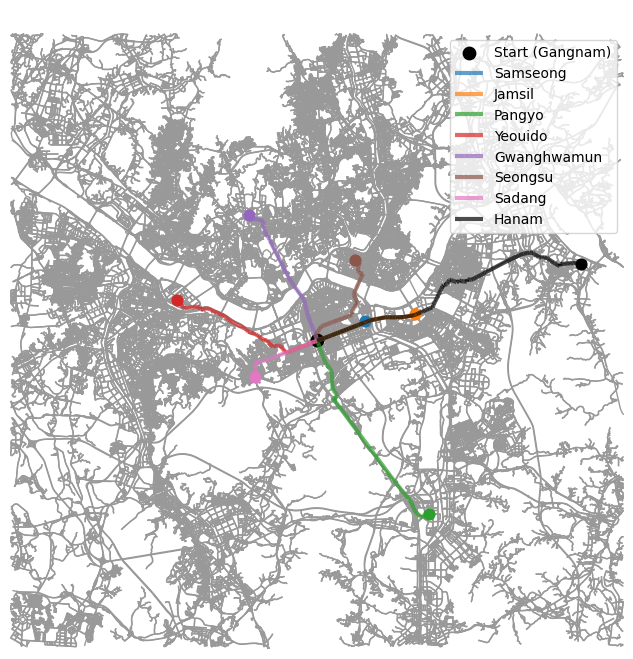

In [4]:
import matplotlib.cm as cm
from matplotlib.collections import LineCollection

fig, ax = ox.plot_graph(G, node_size=0, bgcolor="white", show=False)

colors = cm.tab10(range(len(nodes)))

start_node = ox.distance.nearest_nodes(G, start[1], start[0])

ax.scatter(
    G.nodes[start_node]["x"],
    G.nodes[start_node]["y"],
    c="black",
    s=80,
    label="Start (Gangnam)"
)

for i, (name, end_node) in enumerate(nodes.items()):

    if name == "Hanam":
        color = "black"
    else:
        color = colors[i]

    # 최단 경로 계산
    route = nx.shortest_path(G, start_node, end_node, weight="length")

    edge_lines = []
    for u, v in zip(route[:-1], route[1:]):
        x1, y1 = G.nodes[u]["x"], G.nodes[u]["y"]
        x2, y2 = G.nodes[v]["x"], G.nodes[v]["y"]
        edge_lines.append([(x1, y1), (x2, y2)])

    lc = LineCollection(
        edge_lines,
        colors=[color],
        linewidths=3,
        alpha=0.7,
        label=name
    )
    ax.add_collection(lc)

    ax.scatter(
        G.nodes[end_node]["x"],
        G.nodes[end_node]["y"],
        c=[color],
        s=60
    )

ax.set_title(
    "Shortest Routes from Gangnam to Major Destinations",
    color="white",
    fontsize=14
)

ax.legend(loc="upper right")

ax.autoscale()
plt.show()

---

#### **6. KPI 정의 및 계산**
각 경로의 도로 구조 특성을 정량화하기 위해 다음 KPI를 정의하였다.  
  
##### **6-1. 기본 KPI 정의**
**1. 거리(Distance, km):**  
경로에 포함된 모든 도로 길이 합  
  
**2. 교차로 수(Intersections):**   
경로 상에서 degree ≥ 3인 노드로 정의하였다.  
  
이는 두 개 이상의 도로가 만나는 지점으로,  
실제 운전에서 방향 선택 또는 신호 대기가 발생할 가능성이 높은 지점이기 때문이다.  
  
단순 직선 도로 연결(degree = 2)은 교차로로 간주하지 않았다.
  
**3. 교차로 밀도(Intersection Density):**  
km당 교차로 수  
  
**4. 회전 수(Turns):**  
경로 상에서 방향 변화 각도가 ±30° 이상인 경우를 회전으로 정의하였다.  
또한 각도 부호를 기준으로 좌회전과 우회전을 구분하였다.  
- angle > +30° → 좌회전  
- angle < -30° → 우회전  
- -30° ~ +30° → 직진  
  
본 회전 정의는 **각도 기반 단순화 모델**로,  
실제 내비게이션의 턴 분류 로직과는 차이가 있을 수 있다.  
그러나 경로 간 상대적인 구조 비교에는 유효한 기준으로 활용 가능하다.  
  
또한, 좌회전은 일반적으로 신호 대기 시간이 길어질 가능성이 있으므로 지연이 클 것으로 가정하였다.  
다만 본 분석에서는 실제 신호 데이터를 반영하지 않았기 때문에,  
이는 가정 기반 모델링 요소이다.

In [ ]:
import math

start_node = ox.distance.nearest_nodes(G, start[1], start[0])
start_name = "Gangnam"

# -----------------------------
# KPI 계산
# -----------------------------
results = []

for name, end_node in nodes.items():

    # 최단 경로 계산
    route = nx.shortest_path(G, start_node, end_node, weight="length")

    # ==============================
    # KPI 1 : 거리
    # ==============================
    edges = ox.routing.route_to_gdf(G, route)
    distance_m = edges["length"].sum()
    distance_km = distance_m / 1000

    # ==============================
    # KPI 2 : 교차로 수
    # ==============================
    intersections = sum(1 for node in route if G.degree[node] >= 3)

    # ==============================
    # KPI 3 : 교차로 밀도
    # ==============================
    intersection_density = intersections / distance_km

    # ==============================
    # KPI 4 : 회전 수 (좌/우 구분)
    # ==============================
    left_turn = 0
    right_turn = 0

    for i in range(len(route) - 2):
        node1, node2, node3 = route[i], route[i+1], route[i+2]

        x1, y1 = G.nodes[node1]["x"], G.nodes[node1]["y"]
        x2, y2 = G.nodes[node2]["x"], G.nodes[node2]["y"]
        x3, y3 = G.nodes[node3]["x"], G.nodes[node3]["y"]

        angle = math.degrees(
            math.atan2(y3 - y2, x3 - x2) -
            math.atan2(y1 - y2, x1 - x2)
        )

        # 각도 정규화 (-180 ~ 180)
        if angle > 180:
            angle -= 360
        elif angle < -180:
            angle += 360

        if angle > 30:
            left_turn += 1
        elif angle < -30:
            right_turn += 1

    turn_count = left_turn + right_turn

    results.append({
        "route": f"{start_name} → {name}",
        "distance_km": round(distance_km, 2),
        "intersections": intersections,
        "intersection_density": round(intersection_density, 2),
        "turns": turn_count,
        "left_turns": left_turn,
        "right_turns": right_turn
    })

df = pd.DataFrame(results)
df

,route,distance_km,intersections,intersection_density,turns,left_turns,right_turns
0,Gangnam → Samseong,3.50,37,10.57,35,17,18
1,Gangnam → Jamsil,6.78,58,8.56,56,27,29
2,Gangnam → Pangyo,15.00,60,4.00,58,30,28
3,Gangnam → Yeouido,10.95,76,6.94,74,33,41
4,Gangnam → Gwanghwamun,9.92,81,8.16,79,46,33
5,Gangnam → Seongsu,7.65,79,10.32,77,43,34
6,Gangnam → Sadang,5.24,56,10.68,54,22,32
7,Gangnam → Hanam,19.77,185,9.36,183,89,94


##### **6-2. 파생 KPI : 복잡도 지수 (Complexity Score)**  
경로의 운전 난이도와 경로 안내 복잡도를 정량화하기 위해 **복잡도 지수**를 정의하였다.  
회전은 교차로 대비 상대적으로 영향이 작다고 가정하여 낮은 가중치를 적용하였다.  
(해당 가중치는 경험적 설정이며, 향후 데이터 기반으로 최적화 가능하다)
  
`Complexity Score`  
`= Intersection Density + (Turns × 0.1)`
  
이 지표를 통해  
- 도심 혼잡 경로
- 회전 많은 복잡 경로
- 직선형 이동 경로  
  
를 비교할 수 있다.

In [6]:
df["complexity_score"] = df["intersection_density"] + (df["turns"] * 0.1)
df = df.sort_values("complexity_score", ascending=False)
df

,route,distance_km,intersections,intersection_density,turns,left_turns,right_turns,complexity_score
7,Gangnam → Hanam,19.77,185,9.36,183,89,94,27.66
5,Gangnam → Seongsu,7.65,79,10.32,77,43,34,18.02
6,Gangnam → Sadang,5.24,56,10.68,54,22,32,16.08
4,Gangnam → Gwanghwamun,9.92,81,8.16,79,46,33,16.06
3,Gangnam → Yeouido,10.95,76,6.94,74,33,41,14.34
1,Gangnam → Jamsil,6.78,58,8.56,56,27,29,14.16
0,Gangnam → Samseong,3.50,37,10.57,35,17,18,14.07
2,Gangnam → Pangyo,15.00,60,4.00,58,30,28,9.80


---

#### **7. 경로 KPI 시각화**
KPI별 경로 비교를 통해 각 경로의 도로 구조 특성을 직관적으로 확인한다.  
  
##### **7-1. 거리 비교**

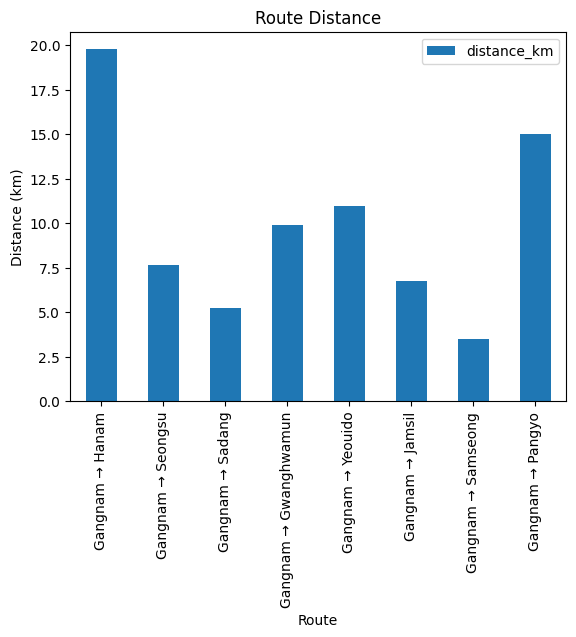

In [8]:
df.plot(x="route", y="distance_km", kind="bar")

plt.title("Route Distance")
plt.ylabel("Distance (km)")
plt.xlabel("Route")
plt.show()

##### **7-2. 교차로 수**

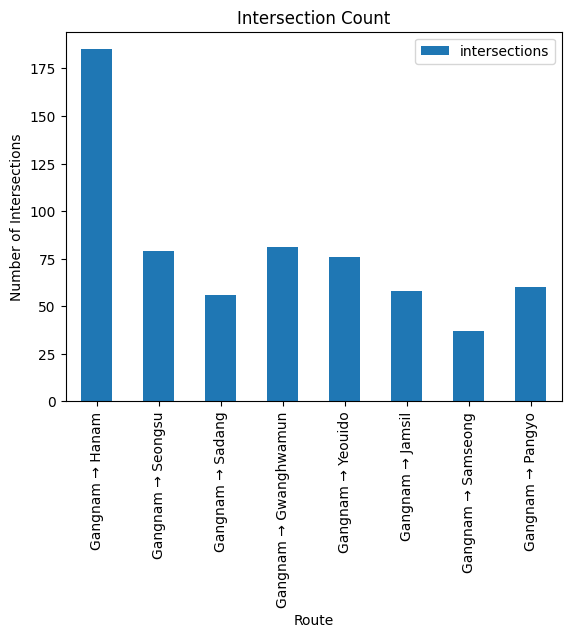

In [9]:
df.plot(x="route", y="intersections", kind="bar")

plt.title("Intersection Count")
plt.ylabel("Number of Intersections")
plt.xlabel("Route")
plt.show()

##### **7-3. 교차로 밀도**

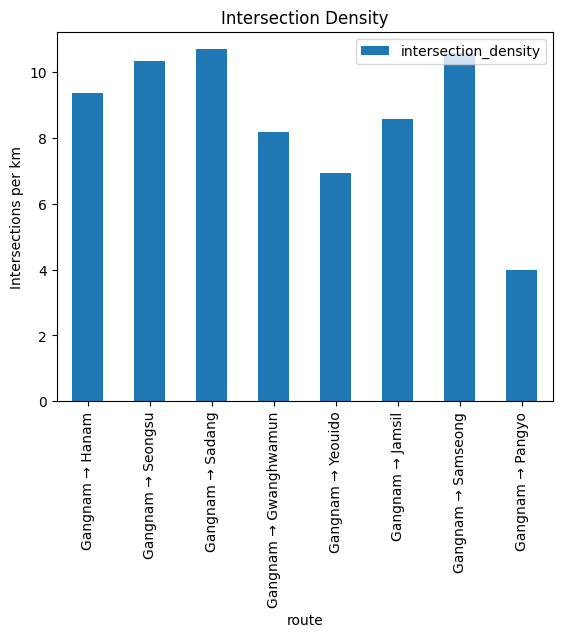

In [10]:
df.plot(x="route", y="intersection_density", kind="bar")

plt.title("Intersection Density")
plt.ylabel("Intersections per km")
plt.show()

##### **7-4. 회전 수**

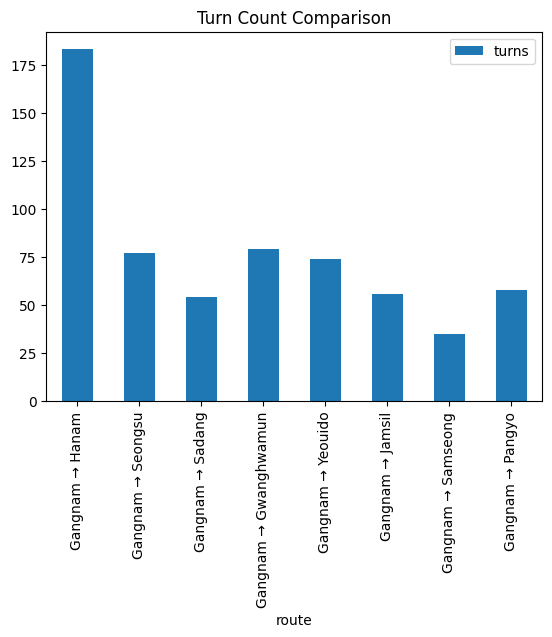

In [11]:
df.plot(x="route", y="turns", kind="bar")

plt.title("Turn Count Comparison")
plt.show()

#### **7-5. 복잡도 지수**
- 교차로 밀도와 회전 수를 결합하여 경로의 운전 난이도와 안내 복잡도를 정량화한 지표

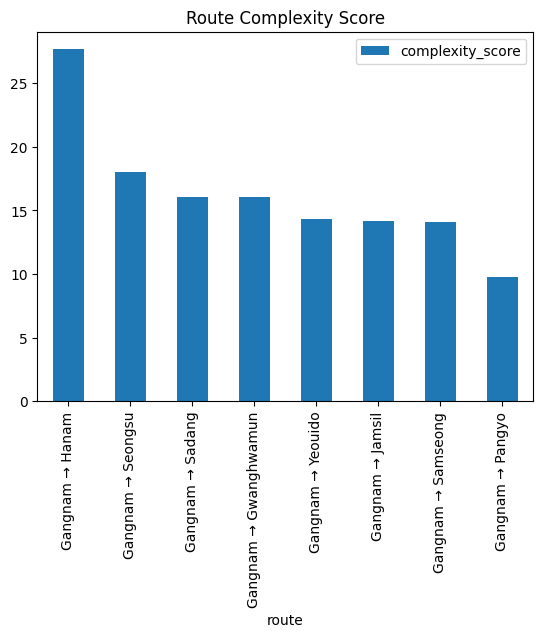

In [12]:
df.plot(x="route", y="complexity_score", kind="bar")

plt.title("Route Complexity Score")
plt.show()

##### **7-6. KPI 종합 해석**
경로별 KPI 비교 결과 다음과 같은 **도로 구조 특성 차이**가 확인되었다.  
  
**1️⃣ 장거리 외곽 경로 (강남 → 하남)**  
- 거리와 회전 수가 매우 높아 복잡도 지수가 가장 크게 나타남
- 거리 영향으로 인해 절대적인 ETA가 높게 나타나는 유형  
- **도심 + 외곽이 혼합된 구조로, 이후 정의할 Mixed 유형에 가까운 특성을 보임**    
  
**2️⃣ 도심 내부 이동 경로 (강남 → 성수, 사당)**  
- 교차로 밀도와 회전 수가 높은 편
- 특히 좌회전 비중이 높은 경우 본 분석의 가정에 따라 신호 대기 시간이 증가할 가능성 있음
- **도심 주행 특성이 강한 경로 유형**  
  
**3️⃣ 도심 중심 이동 경로 (강남 → 광화문, 여의도)**  
- 주요 업무지구로 이동하는 경로
- 교차로 밀도는 일부 도심 내부 경로 대비 중간 수준
- 구조적 복잡성과 거리 요소가 함께 작용하는 경로 
  
**4️⃣ 일반 도심 이동 경로 (강남 → 잠실, 삼성)**  
- 잠실은 중간 수준의 도심 이동 
- 삼성은 교차로 밀도가 높은 도심형 경로 특성을 일부 보임
- 비교적 전형적인 도심 이동 경로  
  
**5️⃣ 간선도로 중심 경로 (강남 → 판교)**  
- 교차로 밀도가 가장 낮고 직선 간선도로 비중이 높은 이동 구조
- 구조적으로 단순하고 주행 난이도가 낮지만,  
  거리 영향으로 인해 총 ETA는 상대적으로 길게 나타나는 경로
- **이후 정의할 Highway 유형에 가까운 특성을 보임**  

본 분석에서는 경로 간 거리 차이가 존재하기 때문에,  
도로 구조가 ETA에 미치는 영향을 독립적으로 분리하여 해석하는 데에는 한계가 있다.  
  
다만 동일 거리 내 비교가 아닌 상황에서도,  
도로 구조 KPI를 통해 각 경로의 주행 특성을 설명할 수 있음을 확인하였다.

##### **7-7. 시사점**
분석 결과 각 경로는 거리뿐 아니라  
**교차로 밀도와 회전 수에 따라 서로 다른 도로 구조 특성**을 가지는 것으로 나타났다.  

특히 본 분석에서는  
ETA가 거리의 영향을 크게 받는 경향을 보였으나,  

도로 구조 KPI를 통해  
각 경로의 **주행 특성을 보다 세분화하여 설명할 수 있음**을 확인하였다.  

동일한 ETA를 가지더라도 경로에 따라  
시간의 구성 요소(거리, 교차로, 회전 구조)가 다르게 나타날 수 있다.  

이는 내비게이션 서비스에서  
단순 거리 기반 경로 추천만으로는  
실제 주행 특성을 충분히 반영하기 어렵다는 점을 시사한다.  

따라서 내비게이션 서비스에서는 거리 기반 경로 추천 외에도  
**도로 구조 KPI**를 반영한 경로 평가 로직 설계가 필요하다.  
- 교차로 수  
- 교차로 밀도  
- 회전 수  
- 경로 복잡도 지수  

이를 활용하면 다음과 같은 서비스 개선이 가능하다.  
- 경로 추천 알고리즘 개선  
- ETA 보정 로직 설계  
- 사용자 운전 난이도 기반 경로 안내  

---

#### **8. 도로 구조 기반 ETA 분석**
실제 내비게이션 서비스에서는  
**실시간 교통, 신호 체계, 도로 속도 제한 등** 다양한 요소가 함께 고려된다.  
  
따라서 본 분석에서는 이러한 요소 중  
**도로 구조 특성이 ETA에 미치는 영향을 분리하여 탐색하는 것**을 목적으로 한다.  
  
본 분석의 ETA는 실제 교통 데이터를 활용한 예측 모델이 아니라,  
**도로 구조 요소가 ETA에 미치는 영향을 설명하기 위한 시뮬레이션 모델**이다.  
  
각 파라미터(평균 속도, 교차로 지연, 회전 지연)는  
경로 구조가 ETA에 미치는 영향을 설명하기 위한 목적에서 설정되었다.

##### **8-1. ETA 계산식**
회전은 단순 개수가 아닌 좌/우 방향에 따라 지연 시간이 다르게 발생할 수 있으므로,  
각도 기반으로 좌회전과 우회전을 구분하여 ETA 모델에 반영하였다.  
  
국내 우측통행 교통 체계상 좌회전은 대기 신호가 필수적이나,  
우회전은 비보호 또는 상시 가능 구간이 많아 가중치를 차등 부여했다.

In [13]:
def estimate_eta(distance_km, intersections, left_turns, right_turns,
                 avg_speed_kmh=40,
                 intersection_delay_sec=5,
                 left_turn_delay_sec=8,
                 right_turn_delay_sec=3):
    
    # 거리 기반 시간
    travel_time_sec = (distance_km / avg_speed_kmh) * 3600
    
    # 교차로 지연
    intersection_time_sec = intersections * intersection_delay_sec
    
    # 회전 지연 (좌/우 분리)
    turn_time_sec = (left_turns * left_turn_delay_sec) + \
                    (right_turns * right_turn_delay_sec)
    
    eta_sec = travel_time_sec + intersection_time_sec + turn_time_sec
    
    return eta_sec / 60

df["eta_min"] = df.apply(lambda x: estimate_eta(
    x["distance_km"],
    x["intersections"],
    x["left_turns"],
    x["right_turns"]
), axis=1)
df

,route,distance_km,intersections,intersection_density,turns,left_turns,right_turns,complexity_score,eta_min
7,Gangnam → Hanam,19.77,185,9.36,183,89,94,27.66,61.638333
5,Gangnam → Seongsu,7.65,79,10.32,77,43,34,18.02,25.491667
6,Gangnam → Sadang,5.24,56,10.68,54,22,32,16.08,17.060000
4,Gangnam → Gwanghwamun,9.92,81,8.16,79,46,33,16.06,29.413333
3,Gangnam → Yeouido,10.95,76,6.94,74,33,41,14.34,29.208333
1,Gangnam → Jamsil,6.78,58,8.56,56,27,29,14.16,20.053333
0,Gangnam → Samseong,3.50,37,10.57,35,17,18,14.07,11.500000
2,Gangnam → Pangyo,15.00,60,4.00,58,30,28,9.80,32.900000


##### **8-2. ETA 시각화**
경로별 ETA 추정값을 시각화하여  
각 경로 간 예상 이동 시간 차이를 확인하였다.

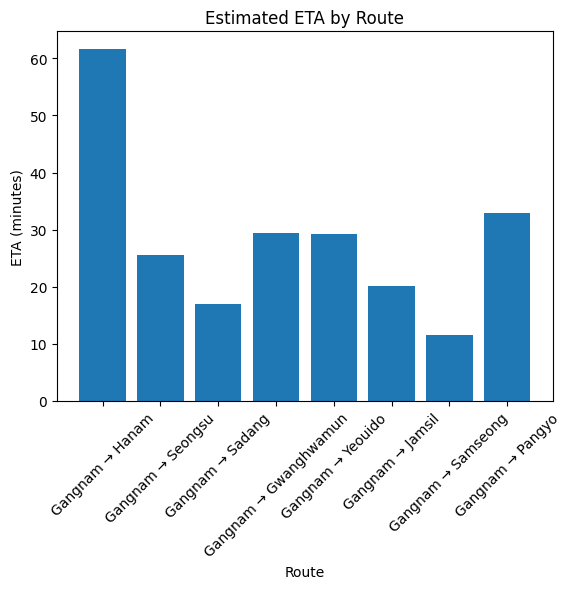

In [14]:
plt.figure()
plt.bar(df["route"], df["eta_min"])
plt.title("Estimated ETA by Route")
plt.ylabel("ETA (minutes)")
plt.xlabel("Route")
plt.xticks(rotation=45)
plt.show()

##### **8-3. KPI와 ETA 관계 탐색**
도로 구조 KPI가 ETA에 미치는 영향을 확인하기 위해  
- 교차로 밀도 vs ETA
- 회전 수 vs ETA  
  
관계를 시각화하였다.  
  
산점도는 **핵심 구조 변수(교차로 밀도, 회전 수)** 중심으로 분석하고,  
히트맵은 전체 KPI 간 관계를 탐색적으로 확인하기 위해 사용한다.  
      
거리는 ETA에 가장 큰 영향을 주는 변수이지만,  
본 분석에서는 거리 외 구조적 요인이 시간에 미치는 영향을  
분리하여 확인하기 위해 산점도에서 제외한다.  
   

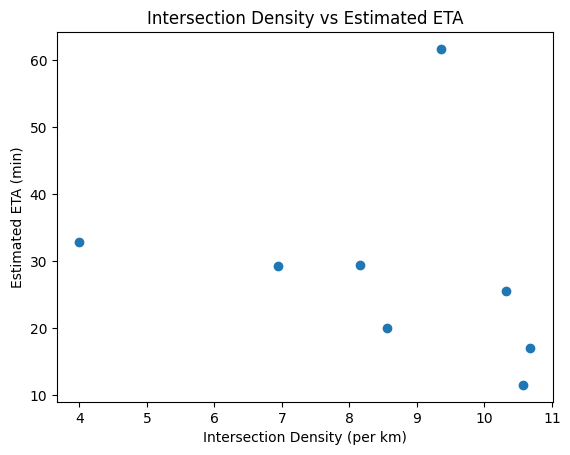

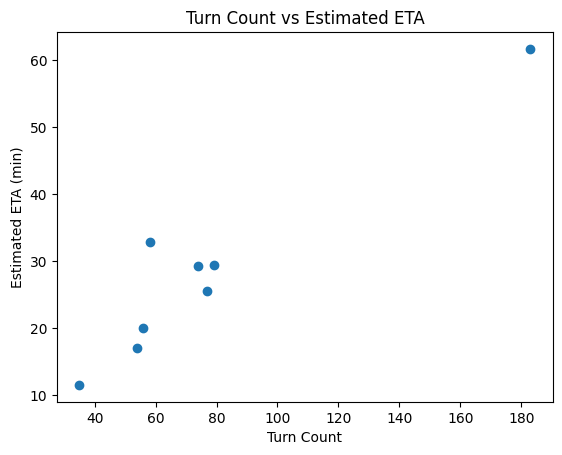

In [15]:
# 교차로 밀도 vs ETA
plt.figure()
plt.scatter(df["intersection_density"], df["eta_min"])
plt.title("Intersection Density vs Estimated ETA")
plt.xlabel("Intersection Density (per km)")
plt.ylabel("Estimated ETA (min)")
plt.show()


# 회전 수 vs ETA
plt.figure()
plt.scatter(df["turns"], df["eta_min"])
plt.title("Turn Count vs Estimated ETA")
plt.xlabel("Turn Count")
plt.ylabel("Estimated ETA (min)")
plt.show()

**해석**

- **Intersection Density vs ETA**

    교차로 밀도와 ETA 간의 관계는 단순한 선형 관계로 나타나지 않았다.  

    이는 ETA가 거리, 교차로 수, 회전 구조 등  
    여러 요소가 결합된 결과이기 때문이다.  

    특히 교차로 밀도가 높더라도  
    경로 길이가 짧거나 회전 수가 적은 경우 ETA가 낮게 나타날 수 있어,  
    단일 KPI만으로 ETA를 설명하기에는 한계가 있다.  
  
- **Turn Count vs ETA**

    회전 수가 많은 경로일수록 ETA가 증가하는 경향이 일부 관찰되었다.  

    다만 비슷한 회전 수 구간에서도 ETA 분산이 존재하며,  
    거리 등 다른 변수의 영향이 함께 작용하기 때문에  
    회전 수의 단독 효과로 해석하기에는 한계가 있다.  

    특히 본 분석에서는 회전을 좌회전과 우회전으로 구분하여 반영하였으며,  
    좌회전의 경우 더 큰 지연 가중치를 부여하였기 때문에  
    회전 수와 ETA 간의 관계에는 모델 구조의 영향이 일부 반영되어 있다.  

    따라서 회전 수는 ETA에 영향을 주는 요소 중 하나로 해석할 수 있으나,  
    독립적인 설명 변수라기보다는 다른 KPI와 결합된 구조적 요소로 보는 것이 적절하다.  

→ 종합적으로, ETA는 단일 KPI로 설명되기보다는  
거리, 교차로, 회전 구조 등 다양한 요소가 결합된 결과이며,  

도로 구조 KPI는  
이러한 ETA가 **어떤 구조적 요인으로 구성되어 있는지를 설명하는 역할**을 한다.  

따라서 보다 정밀한 ETA 분석을 위해서는  
다변량 기반 KPI를 활용한 ETA 모델링 및 경로 평가 로직 설계가 필요함을 시사한다.

---

#### **9. KPI 영향도 분석**
본 상관분석은 제한된 경로 샘플을 기반으로 수행되었기 때문에 통계적 일반화에는 한계가 있다.  
따라서 샘플 수가 제한적이므로 상관계수 해석에는 주의가 필요하다.
  
다만 KPI 간 관계를 탐색적으로 확인하기 위한 목적으로 활용하였다.

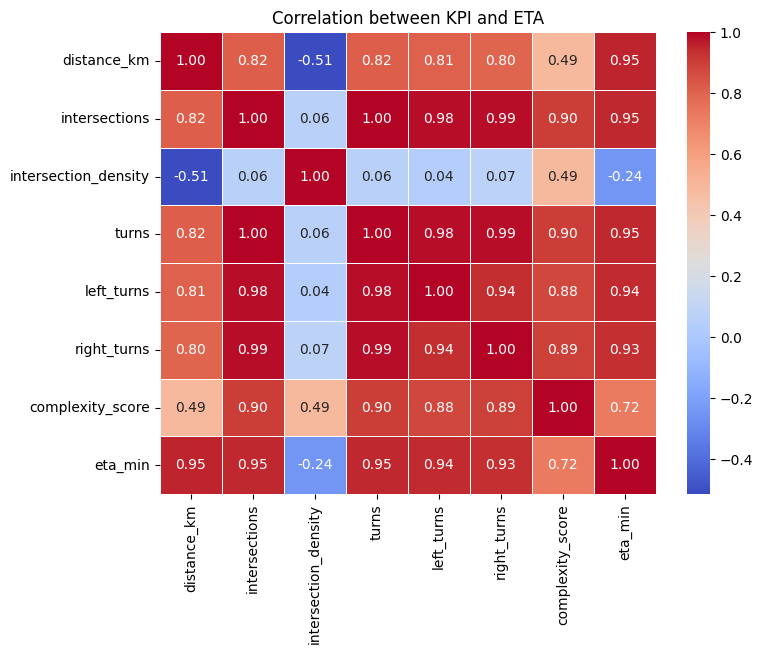

In [ ]:
import seaborn as sns

corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation between KPI and ETA")
plt.show()

**해석**  

- **Distance** :  
ETA와 가장 높은 상관관계를 보이며, 이동 시간의 기본적인 결정 요소로 작용  

- **Intersection Density** :  
독립적인 영향보다는 다른 요소들과 결합되어 작용  

- **Turns** :  
ETA와 높은 상관관계가 관찰되었으나,  
intersections 및 좌/우회전 수와 강하게 연관되어 있어  
독립적인 영향으로 해석하기에는 한계가 있음    
또한 샘플 수가 제한적이고, ETA가 구조 기반 시뮬레이션 모델로 계산되었기 때문에  
모델 구조의 영향이 일부 반영된 결과로 해석할 필요가 있음  

이 결과는 ETA가 단일 요소가 아닌,  
**여러 도로 구조 요소가 결합된 결과**임을 보여준다.  

또한 도로 구조 KPI를 통해  
단순 시간 비교를 넘어 **경로별 주행 특성을 해석할 수 있음**을 확인하였다.

---

##### **10-1. 분석 인사이트**
- **도심 경로:**  
  교차로 밀도와 회전 수가 높으며, 본 분석의 가정에 따라 좌회전 비중 증가 시 지연 가능성 증가  

- **외곽 이동 경로:**  
  직선 구간 비중이 높고 구조적으로 단순하지만 거리 영향이 큼  

- **복잡도 지수:**  
  도로 구조 차이를 단일 지표로 정량화하여 경로 간 비교 가능  

- **핵심 인사이트:**  
  ETA는 거리의 영향을 크게 받지만,  
  도로 구조 KPI를 통해 **시간이 어떤 요소로 구성되는지 설명 가능**  

##### **10-2. 서비스 활용 가능성**

본 분석에서 정의한 도로 구조 KPI는 단순 분석 지표를 넘어,  
내비게이션 서비스의 **경로 추천 및 ETA 보정 로직에 직접 활용 가능한 요소**로 확장할 수 있다.  

**1️⃣ 경로 추천 알고리즘 설계**  
  
기존 내비게이션은 주로 **최단 거리 또는 최소 시간(ETA)** 기준으로 경로를 추천한다.  
그러나 본 분석의 KPI를 활용할 경우, 다음과 같은 **다중 기준 경로 추천 전략**을 설계할 수 있다.  

- **Fastest Route (최단 시간 경로)**  
  → ETA 최소화 기준  

- **Simple Route (저복잡도 경로)**  
  → Complexity Score 최소화  
  → 교차로 및 회전 수가 적어 운전 난이도가 낮은 경로  

- **Balanced Route (균형 경로)**  
  → ETA + Complexity Score를 함께 고려한 혼합 최적화  
  
예시)  
`Route Score = ETA + α × Complexity Score`  

→ 사용자 성향(초보 운전자, 출퇴근 사용자 등)에 따라  
α 값을 조정하여 맞춤형 경로 추천이 가능하다.  

**2️⃣ ETA 보정 로직 설계**  
  
기존 ETA는 거리 및 평균 속도 중심으로 계산되는 경우가 많으나,  
본 분석의 KPI를 활용하면 **경로 구조 기반 보정 로직**을 추가할 수 있다.  
  
예시)  
`ETA = Base Travel Time`  
`+ (Intersection Count × Intersection Delay)`  
`+ (Left Turn × Left Turn Delay)`  
`+ (Right Turn × Right Turn Delay)`  
  
→ 이를 통해  
- 도심 경로: 신호 및 회전 지연 반영  
- 간선도로 중심 경로: 구조적 단순성 반영  
  
과 같은 **경로 특성별 ETA 정밀도 개선**이 가능하다.  

**3️⃣ 경로 유형 기반 사용자 안내 기능**  
  
도로 구조 KPI를 기반으로 경로를 다음과 같이 분류할 수 있다.  
- **Urban**: 교차로 밀도와 회전 수가 높은 도심 경로  
- **Highway**: 직선 구간 비중이 높은 단순 경로  
- **Mixed**: 도심과 간선도로가 혼합된 경로

In [21]:
density_q75 = df["intersection_density"].quantile(0.75)
turn_q25 = df["turns"].quantile(0.25)

def classify_route(row):
    if row["intersection_density"] >= density_q75:
        return "Urban"
    elif row["turns"] <= turn_q25:
        return "Highway"
    else:
        return "Mixed"

df["route_type"] = df.apply(classify_route, axis=1)
df[["route", "route_type"]]

,route,route_type
7,Gangnam → Hanam,Mixed
5,Gangnam → Seongsu,Mixed
6,Gangnam → Sadang,Urban
4,Gangnam → Gwanghwamun,Mixed
3,Gangnam → Yeouido,Mixed
1,Gangnam → Jamsil,Mixed
0,Gangnam → Samseong,Urban
2,Gangnam → Pangyo,Mixed


본 분석 결과, 대부분의 경로가 Mixed 유형으로 나타났으며  
이는 서울 도로 구조 특성상 완전히 단순한 경로가 드물기 때문으로 해석된다.  
향후 KPI 확장 및 기준 개선 시,  
보다 명확한 경로 유형 분류가 가능할 것으로 판단된다.  
  
→ 이러한 분류를 활용하면 사용자에게  
- “신호 많은 복잡 경로”  
- “단순하지만 다소 우회하는 경로”  
  
와 같이 **경로 특성 기반 설명형 안내 기능** 제공이 가능하다.  
  
또한 이러한 경로 특성 정보는  
앞서 정의한 경로 추천 전략(Fast / Simple / Balanced)과 결합되어  
사용자 선택 기반 경로 안내 기능으로 확장될 수 있다.

**4️⃣ 신규 서비스 기능 제안**  
  
본 분석에서 도출된 Complexity Score는 다음과 같은  
**신규 내비게이션 기능 설계에 활용 가능하다.**  
  
- **최소 회전 경로 옵션**  
  → 회전 수 및 Complexity Score 최소화 경로 제공  
  
- **운전 난이도 기반 경로 추천**  
  → 초보 운전자에게 단순 경로 우선 추천  
  
- **Navigation Complexity Index (NCI)**  
  → 특정 지역 및 경로의 복잡도 변화 모니터링 지표로 활용  
  

→ 종합적으로, 본 분석의 KPI는 단순 분석 지표를 넘어  
**경로 추천, ETA 계산, 사용자 경험 개선까지 연결 가능한 서비스 설계 요소**로 활용될 수 있다.

#### **10-3. 모니터링 KPI 제안**
**Navigation Complexity Index (NCI)**
- 정의: 경로 복잡도 지수 기반 서비스 모니터링 지표
- 목적: 사용자 주행 난이도 및 경로 안내 품질 모니터링  
  
**활용**
- 특정 지역 복잡도 상승 감지
- 경로 안내 난이도 증가 구간 탐지
- 사용자 경험 저하 사전 대응

---

#### **11. 결론**
본 분석에서는 OSM 도로 네트워크를 활용하여  
강남 출발 주요 경로의 **도로 구조 특성**을 분석하였다.  

이를 통해  
- 경로 복잡도 지표 설계  
- KPI 기반 ETA 시뮬레이션  
- 도로 구조 요소 기반 경로 특성 분석  

을 수행하였다.  

분석 결과 ETA는 거리의 영향을 크게 받는 것으로 나타났으나,  
도로 구조 KPI를 통해 각 경로의 주행 특성을 보다 세분화하여 설명할 수 있었다.  

즉, 본 분석은 단순 이동 시간 비교를 넘어  
**ETA를 구성하는 구조적 요인을 해석할 수 있는 지표 체계를 구축했다는 데 의의가 있다.**  

이러한 접근은 내비게이션 서비스에서  
- 경로 추천 알고리즘 개선  
- ETA 보정 로직 설계  
- 사용자 맞춤형 경로 안내  

등에 활용될 수 있다.  

본 분석은 구조 기반 시뮬레이션으로,  
실제 서비스 적용 시에는 교통량, 신호 체계, 시간대별 속도 데이터 등이 추가적으로 반영되어야 한다.  

향후 실시간 교통 데이터를 결합할 경우  
보다 정밀한 ETA 모델링이 가능할 것으로 기대된다.